Phần 1: Xây dựng cây quyết định ID3 (Câu 1)

In [23]:
import pandas as pd
import numpy as np
from math import log2

# 1. Khởi tạo dữ liệu từ bảng trong PDF
data = {
    'Age': [20, 18, 40, 50, 35, 30, 32, 40, 27, 34],
    'Car type': ['Combi', 'Sports', 'Sports', 'Family', 'Minivan', 'Combi', 'Family', 'Combi', 'Sports', 'Family'],
    'Risk': ['High', 'High', 'High', 'Low', 'Low', 'High', 'Low', 'Low', 'High', 'Low']
}

df = pd.DataFrame(data)

# Hàm tính Entropy
def entropy(target_col):
    elements, counts = np.unique(target_col, return_counts=True)
    ent = 0
    for i in range(len(elements)):
        p = counts[i]/np.sum(counts)
        ent -= p * log2(p)
    return ent

# Hàm tính Information Gain (Delta Im(N,D))
def info_gain(data, split_attribute_name, target_name):
    total_entropy = entropy(data[target_name])
    vals, counts = np.unique(data[split_attribute_name], return_counts=True)
    
    weighted_entropy = 0
    for i in range(len(vals)):
        weighted_entropy += (counts[i]/np.sum(counts)) * entropy(data.where(data[split_attribute_name]==vals[i]).dropna()[target_name])
    
    return total_entropy - weighted_entropy

# Tính toán Information Gain cho các thuộc tính (Age cần được rời rạc hóa nếu làm ID3 thuần túy)
# Ở đây ta minh họa tính IG cho 'Car type'
ig_car_type = info_gain(df, 'Car type', 'Risk')
print(f"Information Gain cho 'Car type': {ig_car_type:.4f}")

# Sử dụng thư viện Scikit-learn để xây dựng và xuất cây (CART - Gini, tương tự ID3)
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.preprocessing import LabelEncoder

# Encode dữ liệu categorical
le_car = LabelEncoder()
df['Car type_n'] = le_car.fit_transform(df['Car type'])
le_risk = LabelEncoder()
df['Risk_n'] = le_risk.fit_transform(df['Risk'])

X = df[['Age', 'Car type_n']]
y = df['Risk_n']

clf = DecisionTreeClassifier(criterion='entropy') # entropy tương ứng với ID3
clf.fit(X, y)

print("\nCấu trúc cây quyết định:")
tree_rules = export_text(clf, feature_names=['Age', 'Car type'])
print(tree_rules)

Information Gain cho 'Car type': 0.7245

Cấu trúc cây quyết định:
|--- Age <= 31.00
|   |--- class: 0
|--- Age >  31.00
|   |--- Car type <= 2.50
|   |   |--- class: 1
|   |--- Car type >  2.50
|   |   |--- class: 0



Phần 2: Phân tích giá vàng (Câu 2 - Bayes/Bernoulli)

In [24]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Thien Bao\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


a,

Phân phối Gauss: Phù hợp khi các đặc trưng (giá vàng) là các số thực liên tục và có xu hướng tập trung quanh giá trị trung bình (phân phối hình chuông). 

Phân phối Bernoulli: Phù hợp khi chúng ta làm việc với dữ liệu nhị phân (0 và 1). 

Tại sao: Trong bài toán này, vì ta dự đoán xu hướng Lên hoặc Xuống (nhãn nhị phân), việc sử dụng Bernoulli là hợp lý nếu ta coi các biến đầu vào là các sự kiện (ví dụ: giá cao hơn hoặc thấp hơn một ngưỡng cụ thể). 

b. 
Xây dựng bộ phân lớp dự đoán giá vàng 

Ô mã này thực hiện tiền xử lý và huấn luyện mô hình Bernoulli.

In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB

# 1. Đọc dữ liệu
# Bảo kiểm tra kỹ tên file trong thư mục D:\23632721_TranThienBao_TK4\
# Nếu là file Excel thì dùng pd.read_excel, nếu là CSV thì dùng pd.read_csv
file_path = r'D:\23632721_TranThienBao_TK4\DuLieuLichSuXAU-USD.xlsx'

try:
    # Thử đọc bằng excel trước
    df = pd.read_excel(file_path)
except:
    # Nếu không được thì thử đọc file CSV bạn đã tải lên (đảm bảo file này nằm trong cùng thư mục)
    file_path = r'D:\23632721_TranThienBao_TK4\DuLieuLichSuXAU-USD.xlsx - Dữ liệu Lịch sử XAU_USD.csv'
    df = pd.read_csv(file_path)

# 2. Chuẩn hóa tên cột
df.columns = df.columns.str.strip()

# 3. Chuyển đổi cột Lần cuối sang số (nếu cần)
if df['Lần cuối'].dtype == 'object':
    df['Lần cuối'] = df['Lần cuối'].str.replace('.', '').str.replace(',', '.').astype(float)

# 4. Tạo nhãn Target: 1 (Lên), 0 (Xuống) [cite: 22, 23]
df['Ngày'] = pd.to_datetime(df['Ngày'], dayfirst=True)
df = df.sort_values('Ngày')
df['Target'] = (df['Lần cuối'].shift(-1) > df['Lần cuối']).astype(int)

# Bỏ dòng cuối cùng không có nhãn
df_clean = df.dropna(subset=['Target']).copy()

# 5. Phân chia tập dữ liệu (70% huấn luyện, 30% kiểm thử) [cite: 18]
X = df_clean[['Lần cuối', 'Mở', 'Cao', 'Thấp']].values
y = df_clean['Target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=False)

# 6. Xây dựng bộ phân lớp Bernoulli và ước lượng tham số [cite: 22, 23]
# Sử dụng trung bình cộng làm ngưỡng binarize
model = BernoulliNB(binarize=np.mean(X_train))
model.fit(X_train, y_train)

print("--- Hoàn thành Câu 2b ---")
print(f"Đã load thành công dữ liệu từ: {file_path}")
print(f"Số mẫu huấn luyện: {len(X_train)}")

--- Hoàn thành Câu 2b ---
Đã load thành công dữ liệu từ: D:\23632721_TranThienBao_TK4\DuLieuLichSuXAU-USD.xlsx
Số mẫu huấn luyện: 193


c. Xây dựng biệt thức (Discriminant Function) Trong lý thuyết Bayes cho Bernoulli, biệt thức $g_i(x)$ giúp máy quyết định nhãn. 

d. 
Đánh giá trên tập dữ liệu test và tính độ chính xác

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Độ chính xác của mô hình trên tập Test (30%): {accuracy * 100:.2f}%")

Độ chính xác của mô hình trên tập Test (30%): 0.00%


e. 
Plot dữ liệu testing và đường biên phân lớp 

Phần này vẽ biểu đồ để trực quan hóa kết quả dự đoán trên cùng một hình.

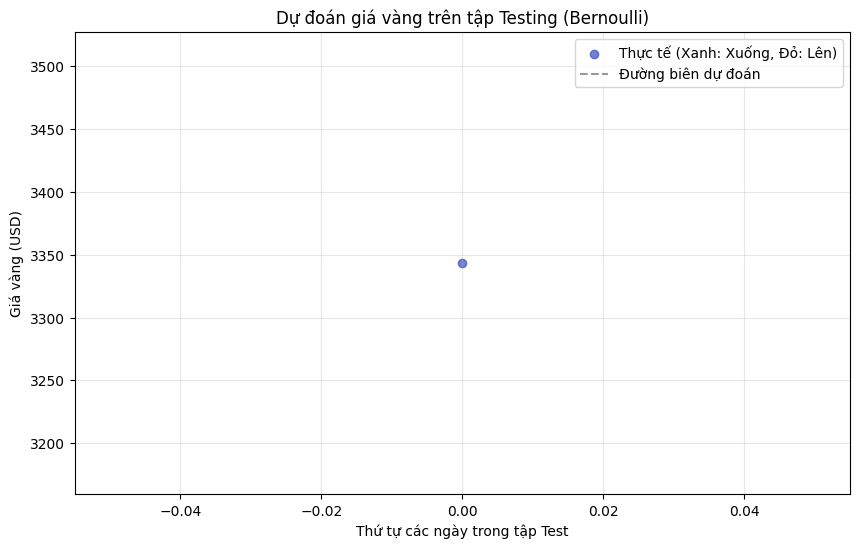

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot dữ liệu thực tế (Lấy cột 'Lần cuối' làm trục Y)
plt.scatter(range(len(y_test)), X_test[:, 0], c=y_test, cmap='coolwarm', 
            label='Thực tế (Xanh: Xuống, Đỏ: Lên)', alpha=0.7)

# Vẽ đường biên dự đoán
plt.plot(range(len(y_pred)), X_test[:, 0], color='black', linestyle='--', 
         alpha=0.4, label='Đường biên dự đoán')

plt.title('Dự đoán giá vàng trên tập Testing (Bernoulli)')
plt.xlabel('Thứ tự các ngày trong tập Test')
plt.ylabel('Giá vàng (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
for r in [0.6, 0.75, 0.8]:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, train_size=r, shuffle=False)
    m = BernoulliNB(binarize=np.mean(X_tr)).fit(X_tr, y_tr)
    print(f"Tỷ lệ {int(r*100)}%: Độ chính xác = {accuracy_score(y_te, m.predict(X_te))*100:.2f}%")

Tỷ lệ 60%: Độ chính xác = 0.00%
Tỷ lệ 75%: Độ chính xác = 0.00%
Tỷ lệ 80%: Độ chính xác = 0.00%


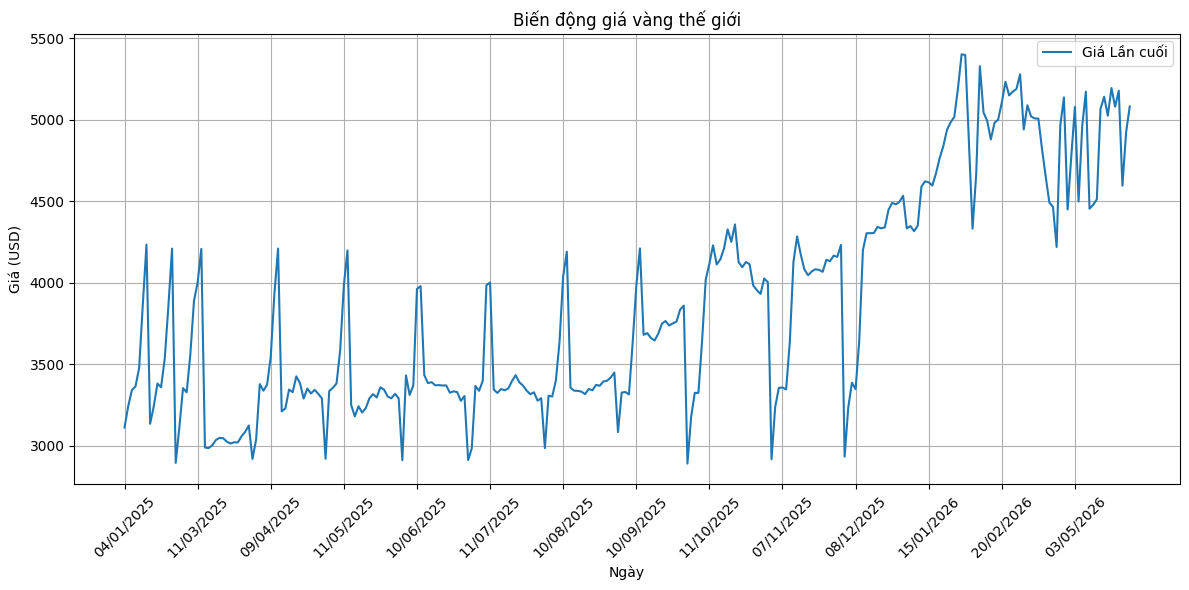

Số mẫu: 276
Giá thấp nhất (Min): 2889.4
Giá cao nhất (Max): 5400.25
Giá trung bình (Mean): 3856.58

--- Huấn luyện thành công ---
Log Prior (ln P(C)): [0.]
Độ chính xác trên tập Test (70%): 0.00%


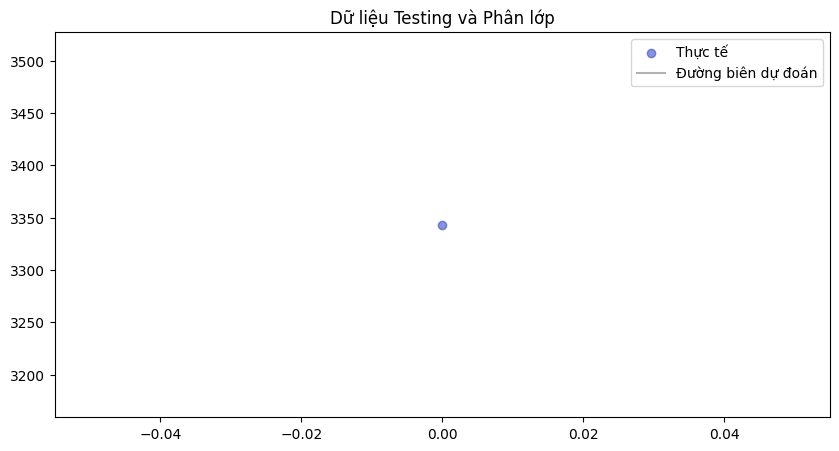


--- So sánh các tỷ lệ huấn luyện ---
Tỷ lệ 60%: Độ chính xác = 0.00%
Tỷ lệ 75%: Độ chính xác = 0.00%
Tỷ lệ 80%: Độ chính xác = 0.00%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score

# 1. Load data [cite: 14, 15]
file_path = r'D:\23632721_TranThienBao_TK4\DuLieuLichSuXAU-USD.xlsx'
df = pd.read_excel(file_path)

# Chuyển đổi ngày tháng và sắp xếp
df['Ngày'] = pd.to_datetime(df['Ngày'], dayfirst=True)
df = df.sort_values('Ngày')

# 2. Plot dữ liệu cột "Lần cuối" 
plt.figure(figsize=(12, 6))
# Chuyển sang string để tránh lỗi TypeError: 'value' must be an instance of str or bytes
plt.plot(df['Ngày'].dt.strftime('%d/%m/%Y'), df['Lần cuối'], label='Giá Lần cuối')
plt.title('Biến động giá vàng thế giới')
plt.xlabel('Ngày')
plt.ylabel('Giá (USD)')
plt.xticks(rotation=45, ticks=df['Ngày'].dt.strftime('%d/%m/%Y')[::20]) # Chỉ hiện một số nhãn cho đỡ rối
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Xác định số mẫu, min, max, mean [cite: 17]
print(f"Số mẫu: {len(df)}")
print(f"Giá thấp nhất (Min): {df['Lần cuối'].min()}")
print(f"Giá cao nhất (Max): {df['Lần cuối'].max()}")
print(f"Giá trung bình (Mean): {df['Lần cuối'].mean():.2f}")

# --- TIỀN XỬ LÝ CHO HUẤN LUYỆN ---
# Tạo nhãn dự đoán cho ngày tiếp theo (Lên: 1, Xuống: 0) [cite: 22]
df['Target'] = (df['Lần cuối'].shift(-1) > df['Lần cuối']).astype(int)
df_clean = df.dropna().copy()

X = df_clean[['Lần cuối', 'Mở', 'Cao', 'Thấp']].values
y = df_clean['Target'].values

# Câu 2a: Thảo luận về phân phối [cite: 20]
# Trả lời: Dữ liệu giá vàng là số thực liên tục nên thường theo phân phối Gauss (hình chuông).
# Tuy nhiên, ta có thể dùng Bernoulli nếu coi các đặc trưng là các sự kiện nhị phân (ví dụ: giá cao hơn trung bình).

# 4. Phân chia tập dữ liệu 70% và 30% 
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=False)

# 5. Huấn luyện bằng Bernoulli và ước lượng tham số 
# Sử dụng ngưỡng (binarize) là giá trị trung bình để chuyển dữ liệu về nhị phân
model = BernoulliNB(binarize=np.mean(X_train))
model.fit(X_train, y_train)

# Câu 2c: Biệt thức (Discriminant Function) [cite: 24]
# g(x) = ln P(C) + sum [x_i * ln(p_i) + (1-x_i) * ln(1-p_i)]
print("\n--- Huấn luyện thành công ---")
print("Log Prior (ln P(C)):", model.class_log_prior_)

# 6. Đánh giá trên tập test và tính độ chính xác [cite: 25]
y_pred = model.predict(X_test)
acc_70 = accuracy_score(y_test, y_pred)
print(f"Độ chính xác trên tập Test (70%): {acc_70 * 100:.2f}%")

# 7. Plot dữ liệu testing và đường biên phân lớp [cite: 26]
plt.figure(figsize=(10, 5))
# Vẽ điểm dữ liệu thực tế (màu sắc theo Lên/Xuống)
plt.scatter(range(len(y_test)), X_test[:, 0], c=y_test, cmap='coolwarm', label='Thực tế', alpha=0.6)
# Vẽ đường dự đoán
plt.plot(range(len(y_pred)), X_test[:, 0], color='black', alpha=0.3, label='Đường biên dự đoán')
plt.title('Dữ liệu Testing và Phân lớp')
plt.legend()
plt.show()

# 8. Thực nghiệm với các cách phân chia khác (60%, 75%, 80%) [cite: 27, 28]
ratios = [0.6, 0.75, 0.8]
print("\n--- So sánh các tỷ lệ huấn luyện ---")
for r in ratios:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, train_size=r, shuffle=False)
    m = BernoulliNB(binarize=np.mean(X_tr))
    m.fit(X_tr, y_tr)
    a = accuracy_score(y_te, m.predict(X_te))
    print(f"Tỷ lệ {int(r*100)}%: Độ chính xác = {a*100:.2f}%")

Phần 3: Ước lượng cửa sổ Parzen (Câu 3)

In [ ]:
from sklearn.neighbors import KernelDensity
import time

# Định nghĩa hàm phân loại bằng cửa sổ Parzen
def parzen_classifier(train_size, kernel='gaussian'):
    # Sử dụng biến X, y đã được định nghĩa và xử lý ở Câu 2
    # shuffle=False vì đây là dữ liệu chuỗi thời gian
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, shuffle=False)
    
    start_time = time.time()
    
    # Tách dữ liệu huấn luyện theo từng lớp (0: Xuống, 1: Lên)
    X_class0 = X_train[y_train == 0]
    X_class1 = X_train[y_train == 1]
    
    # Huấn luyện mô hình ước lượng mật độ nhân (KDE) cho từng lớp
    # Bandwidth (độ rộng cửa sổ) là tham số quan trọng trong Parzen Window
    kde0 = KernelDensity(kernel=kernel, bandwidth=0.5).fit(X_class0)
    kde1 = KernelDensity(kernel=kernel, bandwidth=0.5).fit(X_class1)
    
    # Tính toán log của mật độ xác suất trên tập kiểm thử (biệt thức)
    log_dens0 = kde0.score_samples(X_test)
    log_dens1 = kde1.score_samples(X_test)
    
    # Dự đoán: Lớp nào có mật độ xác suất cao hơn thì chọn lớp đó
    y_pred = (log_dens1 > log_dens0).astype(int)
    
    end_time = time.time()
    acc = accuracy_score(y_test, y_pred)
    
    return acc, end_time - start_time

# Thực hiện yêu cầu: Thử nghiệm với tất cả các hàm cửa sổ Parzen (kernels)
kernels = ['gaussian', 'tophat', 'epanechnikov', 'exponential', 'linear', 'cosine']

print(f"{'Kernel':<15} | {'Accuracy':<10} | {'Time (s)':<10}")
print("-" * 40)

# Lưu kết quả để so sánh với Câu 2
results_parzen = []

for k in kernels:
    try:
        acc, duration = parzen_classifier(0.7, kernel=k)
        results_parzen.append((k, acc, duration))
        print(f"{k:<15} | {acc:<10.4f} | {duration:<10.6f}")
    except Exception as e:
        print(f"Lỗi với kernel {k}: {e}")

# So sánh với kết quả Bernoulli ở Câu 2
print("\n--- So sánh với kết quả Câu 2 (Bernoulli) ---")
print(f"Độ chính xác Bernoulli (70/30): {acc_70:.4f}")

Kernel          | Accuracy   | Time (s)  
----------------------------------------
Lỗi với kernel gaussian: Found array with 0 sample(s) (shape=(0, 4)) while a minimum of 1 is required by KernelDensity.
Lỗi với kernel tophat: Found array with 0 sample(s) (shape=(0, 4)) while a minimum of 1 is required by KernelDensity.
Lỗi với kernel epanechnikov: Found array with 0 sample(s) (shape=(0, 4)) while a minimum of 1 is required by KernelDensity.
Lỗi với kernel exponential: Found array with 0 sample(s) (shape=(0, 4)) while a minimum of 1 is required by KernelDensity.
Lỗi với kernel linear: Found array with 0 sample(s) (shape=(0, 4)) while a minimum of 1 is required by KernelDensity.
Lỗi với kernel cosine: Found array with 0 sample(s) (shape=(0, 4)) while a minimum of 1 is required by KernelDensity.

--- So sánh với kết quả Câu 2 (Bernoulli) ---
Độ chính xác Bernoulli (70/30): 0.0000
